# Install and Import necessary libraries

In [7]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import shap
import pycaret
from scipy.stats import chi2_contingency, f_oneway, iqr
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    jaccard_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    make_scorer, 
    average_precision_score
)
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from jaqpotpy import Jaqpot
from jaqpotpy.datasets import JaqpotTabularDataset
from jaqpotpy.models.sklearn import SklearnModel
from jaqpotpy.doa import Leverage, BoundingBox
from pycaret.classification import get_config
from pycaret.classification import *
from sklearn.model_selection import RepeatedStratifiedKFold

%load_ext watermark
%watermark -a 'Alexandros Angelis' -v -iv -m


The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Author: Alexandros Angelis

Python implementation: CPython
Python version       : 3.11.15
IPython version      : 9.13.0

Compiler    : Clang 20.1.8 
OS          : Darwin
Release     : 25.5.0
Machine     : arm64
Processor   : arm
CPU cores   : 10
Architecture: 64bit

jaqpotpy  : 7.1.0
matplotlib: 3.7.5
numpy     : 1.26.4
pandas    : 2.1.4
pycaret   : 3.3.2
scipy     : 1.11.4
seaborn   : 0.13.2
shap      : 0.51.0
sklearn   : 1.4.2



# General Settings

In [8]:
DATASET = 'cytotoxicity_data'

RANDOM_STATE = 42
NUM_SPLITS = 10

# Upload Cytotoxicity Data and Create DataFrame

In [9]:
# Load Dataset
model = DATASET
df = pd.read_csv(f'{model}.csv')

In [10]:
# Check shape and features of the Dataset
features = df.columns.to_list()
print(f"Original dataset: {df.shape}")
print(f"\nFeature names: \n{features}")

Original dataset: (440, 69)

Feature names: 
['study_id', 'instance', 'monomer_a', 'monomer_b', 'hb_ratio', 'hv_ratio', 'mw', 'mw_units', 'mn', 'mn_units', 'pdi', 'shape', 'thickness', 'units_thickness', 'surface', 'surface_units', 'diameter', 'diameter_units', 'length', 'length_units', 'additive', 'additive1_name', 'additive1_percentage', 'additive1_use', 'additive2_name', 'additive2_percentage', 'additive2_use', 'addtive3_name', 'additive3_percentage', 'additive3_use', 'polymer_percentage', 'iso', 'astm', 'assay', 'cell_line', 'cell_line_type', 'exposure_type', 'no_cells_per_well', 'inoculum_concentration_units', 'culture_medium', 'dilution_medium', 'concentration', 'concentration_units', 'dilution', 'incubation_time', 'incubation_time_units', 'incubation_temperature', 'incubation_temperature_units', 'co2_percentage', 'air', 'extraction_time', 'units_extraction_time', 'extraction_temperature', 'units_extraction_t', 'extraction_medium', 'extraction_surface_area_ratio', 'extraction_sur

Certain Feature Explanation:

- Assay: The experimental method used to measure cytotoxicity.
- Cell line: The specific type of cell used in the experiment.
- Culture medium: The nutrient solution the cells are grown in.
- Number of cells per well: Show how crowded the cells are in the experiment.

In [11]:
# Remove identifiers, units measurements or features with a single value
cols_identifiers_units = ['study_id', 'instance', 'monomer_a', 'monomer_b', 'mw_units', 'mn_units', 'units_thickness', 'surface_units', 'incubation_temperature',
                  'diameter_units', 'length_units', 'additive', 'additive1_name', 'additive2_name', 'addtive3_name', 'iso', 'astm',
                  'inoculum_concentration_units', 'concentration_units', 'incubation_time_units', 'incubation_temperature_units',
                  'units_extraction_time', 'units_extraction_t', 'extraction_surface_area_ratio_units', 'ic_50_units', 'growth_constant_μ_units'
                  ]
df = df.drop(columns=cols_identifiers_units)   
print(f"After column removal: {df.shape}")

After column removal: (440, 43)


In [12]:
# Remove cytotoxicity output related columns
cols_leaky = ['cell_viability_percentage','ic_50', 'growth_constant_μ', 'rgr',
              'toxicity_grade','zone_index','lysis_index', 'growth_inhibition_percentage']
df = df.drop(columns=cols_leaky)   
print(f"After cytotoxicity related columns removal: {df.shape}")

After cytotoxicity related columns removal: (440, 35)


In [13]:
# Remove redundant features
cols_redundant = ['hv_ratio', # hb_ratio + hv_ratio = 100
                  'cell_line_type', # derived from cell_line
                  # 'polymer_percentage' # =100-(additive1+additive2+additive3)percentage, it can be omitted as well
                 ]
df = df.drop(columns=cols_redundant)   
print(f"After cytotoxicity related columns removal: {df.shape}")

After cytotoxicity related columns removal: (440, 33)


# Train/Test Split

In [14]:
# Set the target feature
target = 'toxicity'

# Split features by their type
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in df.columns
                    if c not in numerical_cols and c != target]

print(f"Numerical features ({len(numerical_cols)}):")
for c in numerical_cols: print(f"  - {c}")
print(f"\nCategorical features ({len(categorical_cols)}):")
for c in categorical_cols: print(f"  - {c}")

Numerical features (21):
  - hb_ratio
  - mw
  - mn
  - pdi
  - thickness
  - surface
  - diameter
  - length
  - additive1_percentage
  - additive2_percentage
  - additive3_percentage
  - polymer_percentage
  - no_cells_per_well
  - concentration
  - dilution
  - incubation_time
  - co2_percentage
  - extraction_time
  - extraction_temperature
  - extraction_surface_area_ratio
  - number_of_cells_well

Categorical features (11):
  - shape
  - additive1_use
  - additive2_use
  - additive3_use
  - assay
  - cell_line
  - exposure_type
  - culture_medium
  - dilution_medium
  - air
  - extraction_medium


In [15]:
# Drop rows with null values at the target features to be able to make stratified split
df = df[df[target].notna()]

In [16]:
X = df[numerical_cols + categorical_cols].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size', X_train.shape, 'class proportions', pd.Series(y_train).value_counts()) 
print('\nTest size', X_test.shape, 'class proportions', pd.Series(y_test).value_counts())

Train size (330, 32) class proportions toxicity
non-toxic    253
toxic         77
Name: count, dtype: int64

Test size (83, 32) class proportions toxicity
non-toxic    64
toxic        19
Name: count, dtype: int64


In [17]:
# Check high missing values on the TRAINING set 
# Missing values overview for all columns in the dataset
missing_df = pd.DataFrame({
    'Missing Values':   X_train.isnull().sum(),
    'Missing Percentage (%)': (X_train.isnull().sum() / len(X_train) * 100).round(1)
}).sort_values('Missing Percentage (%)', ascending=False)

# missing_df.to_excel('missing_values.xlsx', index=True)

print(f"Total rows: {len(X_train)}\n")
missing_df

Total rows: 330



,Missing Values,Missing Percentage (%)
surface,326,98.8
number_of_cells_well,319,96.7
extraction_medium,309,93.6
extraction_time,309,93.6
extraction_temperature,303,91.8
extraction_surface_area_ratio,294,89.1
diameter,286,86.7
thickness,272,82.4
dilution,267,80.9
pdi,262,79.4


In [18]:
# Find columns with high number of missing values in the TRAINING set only
miss_thresh = 0.20  # 20% of the values are missing
high_missing_cols_train = [
    c for c in X_train.columns
    if X_train[c].isnull().sum() / len(X_train) > miss_thresh
    and c != 'concentration' # exclude concentration because it plays an important role in cytotoxicity
]

# Apply same column drop to train and test set
X_train = X_train.drop(columns=high_missing_cols_train)
X_test  = X_test.drop(columns=high_missing_cols_train)

# Drop null rows from train and test set
mask_train = X_train.notna().all(axis=1)
X_train = X_train[mask_train]
y_train = y_train[mask_train]

mask_test = X_test.notna().all(axis=1)
X_test = X_test[mask_test]
y_test = y_test[mask_test]

# Check the new train and test sets
print('Train size', X_train.shape, 'class proportions', pd.Series(y_train).value_counts()) 
print('\nTest size', X_test.shape, 'class proportions', pd.Series(y_test).value_counts())

Train size (109, 15) class proportions toxicity
non-toxic    86
toxic        23
Name: count, dtype: int64

Test size (27, 15) class proportions toxicity
non-toxic    21
toxic         6
Name: count, dtype: int64


# Exploratory Data Analysis (fit on train set, apply on train and test set)

## Examine Numerical Features

In [19]:
for column in X_train.select_dtypes(include=[np.number]).columns.tolist():
    print("\n")
    print(X_train[column].describe())



count    109.000000
mean      93.256881
std        6.796518
min       85.000000
25%       88.000000
50%       88.000000
75%      100.000000
max      100.000000
Name: hb_ratio, dtype: float64


count    109.000000
mean      28.812569
std       14.584613
min        0.000000
25%       23.000000
50%       32.900000
75%       33.330000
max       90.000000
Name: additive1_percentage, dtype: float64


count    109.000000
mean      26.464404
std       17.222337
min        0.000000
25%        0.000000
50%       32.900000
75%       33.330000
max       55.000000
Name: additive2_percentage, dtype: float64


count    109.000000
mean       4.691009
std        8.892202
min        0.000000
25%        0.000000
50%        0.000000
75%        1.320000
max       32.000000
Name: additive3_percentage, dtype: float64


count    109.000000
mean      39.145596
std       27.936167
min        6.000000
25%       11.000000
50%       32.900000
75%       33.330000
max      100.000000
Name: polymer_percentage, dtyp

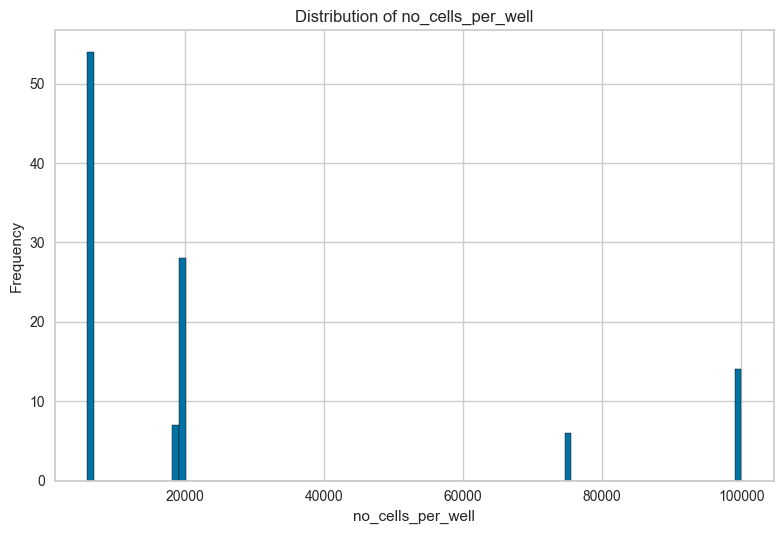



no_cells_per_well
6000.0      54
19000.0      7
20000.0     28
75000.0      6
100000.0    14
Name: count, dtype: int64


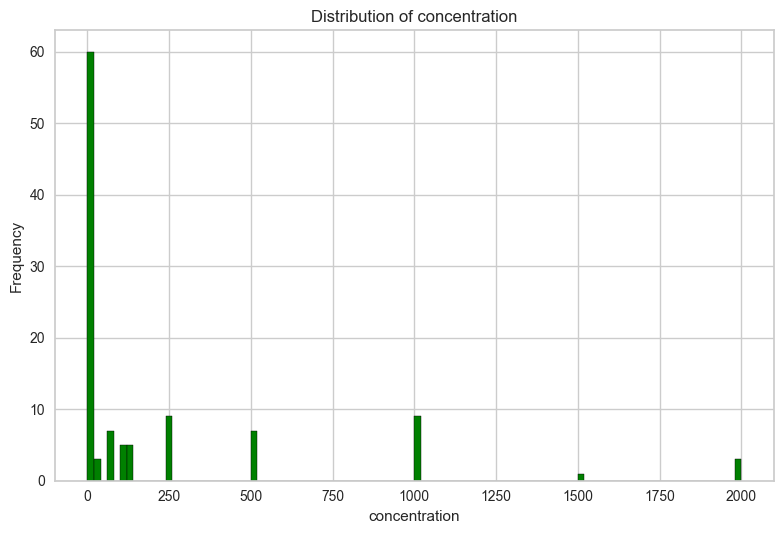



concentration
0.00       10
0.20        9
0.60        6
1.00        2
1.30        8
3.00       10
6.00       11
10.00       2
15.60       2
31.25       3
62.50       7
100.00      5
125.00      5
250.00      9
500.00      7
1000.00     9
1500.00     1
2000.00     3
Name: count, dtype: int64


In [20]:
# Check heavily skewed features (high value of std)

## Plot a histogram of the distribution of no_cells_per_well
X_train['no_cells_per_well'].hist(bins=100, edgecolor='black')
plt.xlabel('no_cells_per_well')
plt.ylabel('Frequency')
plt.title('Distribution of no_cells_per_well')
plt.tight_layout()
# plt.savefig('no_cells_per_well_distribution.png', dpi=600, bbox_inches='tight')
plt.show()
## Check to decide boundaries of no_cells_per_well
print('\n')
print(X_train['no_cells_per_well'].value_counts().sort_index())

## Plot a histogram of the distribution of concentration
X_train['concentration'].hist(bins=100, edgecolor='black', color='green')
plt.xlabel('concentration')
plt.ylabel('Frequency')
plt.title('Distribution of concentration')
plt.tight_layout()
# plt.savefig('concentration_distribution.png', dpi=600, bbox_inches='tight')
plt.show()
## Check to decide boundaries of concentration
print('\n')
print(X_train['concentration'].value_counts().sort_index())

Features 'no_cells_per_well' and 'concentration' will be converded to categorical features because:

- the features are conceptually ordinal/categorical
- their distribution is heavily multimodal (clusters in to clear groups)

In [21]:
# Categorise no_cells_per_wel feature
bins = [0, 10_000, 50_000, float('inf')]
labels = ['low', 'medium', 'high']

X_train['no_cells_per_well'] = pd.cut(X_train['no_cells_per_well'], bins=bins, labels=labels)
X_test['no_cells_per_well']  = pd.cut(X_test['no_cells_per_well'],  bins=bins, labels=labels)

# Check the categories frequency
print(f"Train set: {X_train['no_cells_per_well'].value_counts()}")
print(f"Test set: {X_test['no_cells_per_well'].value_counts()}")

Train set: no_cells_per_well
low       54
medium    35
high      20
Name: count, dtype: int64
Test set: no_cells_per_well
low       18
medium     8
high       1
Name: count, dtype: int64


In [22]:
# Categorise concetration
bins = [float('-inf'), 0, 2.50, 6.00, 62.50, 250.00, float('inf')]
labels = ['zero', 'very_low', 'low', 'medium', 'high', 'very_high']

X_train['concentration'] = pd.cut(X_train['concentration'], bins=bins, labels=labels)
X_test['concentration']  = pd.cut(X_test['concentration'],  bins=bins, labels=labels)

# Check the categories frequency
print(f"Train set: {X_train['concentration'].value_counts()}")
print(f"\nTest set: {X_test['concentration'].value_counts()}")

Train set: concentration
very_low     25
low          21
very_high    20
high         19
medium       14
zero         10
Name: count, dtype: int64

Test set: concentration
very_low     13
medium        4
low           3
very_high     3
zero          2
high          2
Name: count, dtype: int64


## Outlier Detection

In [23]:
apply_outlier_detection = False  # Set to False to skip

if apply_outlier_detection:
    data = X_train.select_dtypes(include=[np.number])
    outlier_mask = pd.DataFrame(False, index=X_train.index, columns=data.columns)

    for col in data.columns:
        Q1 = np.percentile(data[col], 25)
        Q3 = np.percentile(data[col], 75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outlier_mask[col] = (data[col] < lower) | (data[col] > upper)

    outlier_rows = outlier_mask.any(axis=1)
    X_train_clean = X_train[~outlier_rows]
    y_train_clean = y_train[~outlier_rows]

    print(f"Removed {outlier_rows.sum()} outlier rows. Remaining: {len(X_train_clean)}")
else:
    X_train_clean = X_train.copy()
    y_train_clean = y_train.copy()
    print("Outlier detection skipped.")

Outlier detection skipped.


In [24]:
# Check the new categories
for col in X_train.select_dtypes(include=[object]).columns.tolist():
    print("\n")
    print(X_train_clean[col].value_counts())



shape
nanospheres       54
microsphere       20
diblock_star      18
nanoparticle      10
tetra_arm_star     6
linear             1
Name: count, dtype: int64


additive1_use
targeting_ligand    54
responsive          25
filler              10
not_applicable       7
anticancer           7
antibiotic           3
stabilizer           3
Name: count, dtype: int64


additive2_use
stabilizer        54
not_applicable    30
stealth           25
Name: count, dtype: int64


additive3_use
not_applicable    58
active_drug       26
hydrophobe        25
Name: count, dtype: int64


assay
mtt        89
diic1_5    14
mts         6
Name: count, dtype: int64


cell_line
mcf7                  54
ccd_112con            25
jurkat                11
a549                   7
hepg2                  6
bovine_keratocytes     3
ht_29_cells            3
Name: count, dtype: int64


culture_medium
dmem_10fbs_pen_strep    60
dmem_fp                 25
rpmi-1640               14
dmem_fbs_p/s             7
dmem_g1_f10_a

## Handle Categorical Features

In [25]:
def fit_rare_category_collapser(X, cat_cols, min_freq=0.05, other_label='other'):
    """
    Learns which categories are rare from training data only.

    Parameters
    ----------
    X : pd.DataFrame
    cat_cols : list
    min_freq : float
        Minimum proportion to keep a category.
    other_label : str

    Returns
    -------
    rare_map : dict mapping column -> set of rare categories
    """
    rare_map = {}
    for col in cat_cols:
        freq = X[col].value_counts(normalize=True)
        rare_map[col] = set(freq[freq < min_freq].index)
    return rare_map


def transform_rare_categories(X, rare_map, other_label='other'):
    """
    Applies rare category collapsing learned from training data.

    Parameters
    ----------
    X : pd.DataFrame
    rare_map : dict from fit_rare_category_collapser
    other_label : str

    Returns
    -------
    X_transformed : pd.DataFrame
    """
    X = X.copy()
    for col, rare_cats in rare_map.items():
        X[col] = X[col].replace(rare_cats, other_label)
    return X


def fit_merge_small_other(X, cat_cols, min_count=5, other_label='other'):
    """
    Learns from training data which columns have a small 'other' group
    and which named category to merge it into.

    Parameters
    ----------
    X : pd.DataFrame
    cat_cols : list
    min_count : int
        Minimum absolute count for 'other' to be kept as its own category.
    other_label : str

    Returns
    -------
    merge_map : dict mapping column -> target category to absorb 'other'
                (None if 'other' is large enough or doesn't exist)
    """
    merge_map = {}
    for col in cat_cols:
        if other_label not in X[col].values:
            merge_map[col] = None
            continue
        other_count = (X[col] == other_label).sum()
        if other_count < min_count:
            freq = X[col][X[col] != other_label].value_counts()
            least_frequent = freq.index[-1]
            print(f"[{col}] 'other' has only {other_count} rows → merging into '{least_frequent}'")
            merge_map[col] = least_frequent
        else:
            merge_map[col] = None
    return merge_map


def transform_merge_small_other(X, merge_map, other_label='other'):
    """
    Applies the merging of small 'other' groups learned from training data.

    Parameters
    ----------
    X : pd.DataFrame
    merge_map : dict from fit_merge_small_other
    other_label : str

    Returns
    -------
    X_transformed : pd.DataFrame
    """
    X = X.copy()
    for col, target_cat in merge_map.items():
        if target_cat is not None:
            X[col] = X[col].replace(other_label, target_cat)
    return X



cat_cols = X_train_clean.select_dtypes(include=['object', 'category']).columns.tolist()

# Collapse rare categories into 'other' (fit on train only)
rare_map = fit_rare_category_collapser(X_train_clean, cat_cols, min_freq=0.05)
X_train_clean = transform_rare_categories(X_train_clean, rare_map)
X_test_clean = transform_rare_categories(X_test, rare_map)

# Merge small 'other' groups into least frequent named category (fit on train only)
merge_map = fit_merge_small_other(X_train_clean, cat_cols, min_count=5)
X_train_clean = transform_merge_small_other(X_train_clean, merge_map)
X_test_clean = transform_merge_small_other(X_test_clean, merge_map)

# Drop columns with only one category after transformations (fit on train only)
cols_to_drop = [col for col in cat_cols if X_train_clean[col].nunique() <= 1]
X_train_clean = X_train_clean.drop(columns=cols_to_drop)
X_test_clean = X_test_clean.drop(columns=cols_to_drop)
cat_cols = [c for c in cat_cols if c not in cols_to_drop]
print(f"{cols_to_drop} has only 1 category and has been dropped from train set")

[shape] 'other' has only 1 rows → merging into 'tetra_arm_star'
[culture_medium] 'other' has only 3 rows → merging into 'dmem_fbs_p/s'
[] has only 1 category and has been dropped from train set


In [26]:
# Check the new categories
for col in cat_cols:
    print("\n")
    print(X_train_clean[col].value_counts())



no_cells_per_well
low       54
medium    35
high      20
Name: count, dtype: int64


concentration
very_low     25
low          21
very_high    20
high         19
medium       14
zero         10
Name: count, dtype: int64


shape
nanospheres       54
microsphere       20
diblock_star      18
nanoparticle      10
tetra_arm_star     7
Name: count, dtype: int64


additive1_use
targeting_ligand    54
responsive          25
filler              10
not_applicable       7
anticancer           7
other                6
Name: count, dtype: int64


additive2_use
stabilizer        54
not_applicable    30
stealth           25
Name: count, dtype: int64


additive3_use
not_applicable    58
active_drug       26
hydrophobe        25
Name: count, dtype: int64


assay
mtt        89
diic1_5    14
mts         6
Name: count, dtype: int64


cell_line
mcf7          54
ccd_112con    25
jurkat        11
a549           7
hepg2          6
other          6
Name: count, dtype: int64


culture_medium
dmem_10fbs_pen_

In [27]:
y_train_clean = y_train_clean.loc[X_train_clean.index].reset_index(drop=True)
y_test_clean  = y_test.loc[X_test_clean.index].reset_index(drop=True)

X_train_clean = X_train_clean.reset_index(drop=True)
X_test_clean  = X_test_clean.reset_index(drop=True)

assert len(X_train_clean) == len(y_train_clean)
assert len(X_test_clean)  == len(y_test_clean)
print(f"Train: {len(X_train_clean)} rows | Test: {len(X_test_clean)} rows")

Train: 109 rows | Test: 27 rows


# Feature Selection 

In [28]:
numerical_cols = X_train_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_train_clean.columns
                    if c not in numerical_cols and c != target]

print(f"Numerical features ({len(numerical_cols)}):")
for c in numerical_cols: print(f"  - {c}")
print(f"\nCategorical features ({len(categorical_cols)}):")
for c in categorical_cols: print(f"  - {c}")

features_num = numerical_cols
features_cat = categorical_cols

Numerical features (6):
  - hb_ratio
  - additive1_percentage
  - additive2_percentage
  - additive3_percentage
  - polymer_percentage
  - incubation_time

Categorical features (9):
  - no_cells_per_well
  - concentration
  - shape
  - additive1_use
  - additive2_use
  - additive3_use
  - assay
  - cell_line
  - culture_medium


## Mutual Information 

In [29]:
# Check mutual information between features and target  (numerical and categorical features(ordinal encoded))
# Ordinal encode categorical features for mutual information calculation
ordinal_encoder = OrdinalEncoder()
X_train_encoded = X_train_clean.copy()
X_train_encoded[features_cat] = ordinal_encoder.fit_transform(X_train_encoded[features_cat])    
mi_scores = mutual_info_classif(X_train_encoded, y_train_clean, discrete_features=[X_train_encoded.columns.get_loc(c) for c in features_cat], random_state=10)
mi_scores_series = pd.Series(mi_scores, index=X_train_encoded.columns).sort_values(ascending=False)
print("Mutual Information Scores:")
print(mi_scores_series)
mi_scores_series.to_excel('mi_scores_cytotoxicity.xlsx')

Mutual Information Scores:
additive1_percentage    0.315861
polymer_percentage      0.301795
additive1_use           0.196738
cell_line               0.182172
additive2_percentage    0.177036
additive3_percentage    0.162405
culture_medium          0.159840
shape                   0.149442
additive3_use           0.121013
hb_ratio                0.070957
additive2_use           0.063648
concentration           0.057891
incubation_time         0.038127
assay                   0.033872
no_cells_per_well       0.022745
dtype: float64


## Kendal correlation (Num vs Num)

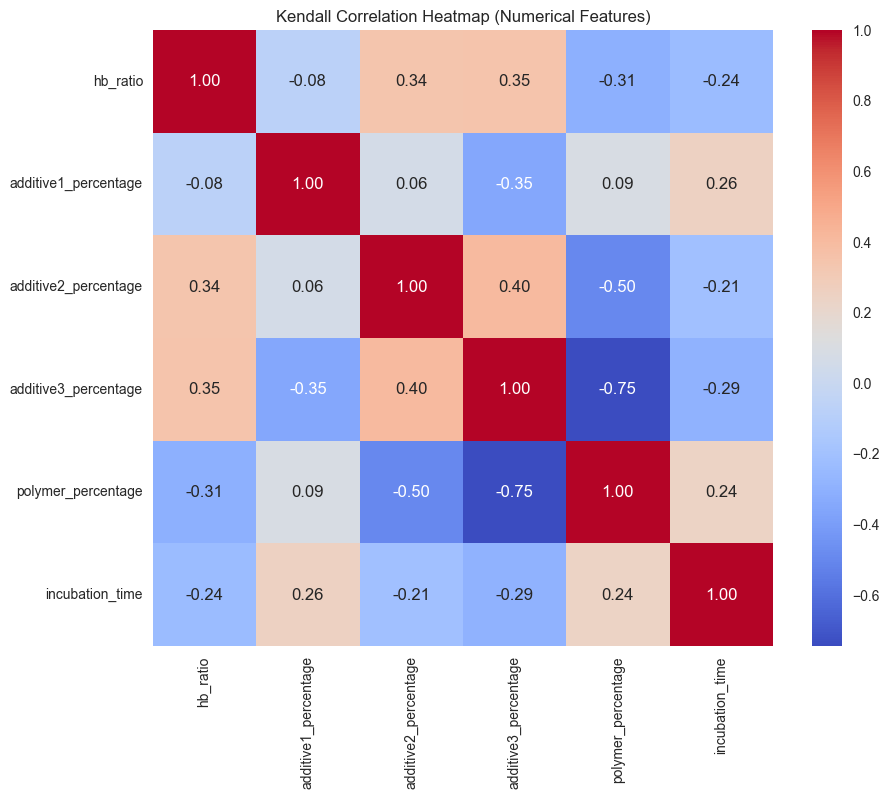

In [30]:
# Use Kendall correlation for numerical features between them
kendall_corr = X_train_clean[numerical_cols].corr(method='kendall')
plt.figure(figsize=(10, 8))
sns.heatmap(kendall_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Kendall Correlation Heatmap (Numerical Features)')
plt.savefig('Kendall Correlation Heatmap - Cytotoxicity Model.png', dpi=600, bbox_inches='tight')

plt.show()

## Cramér's V (Cat vs Cat)

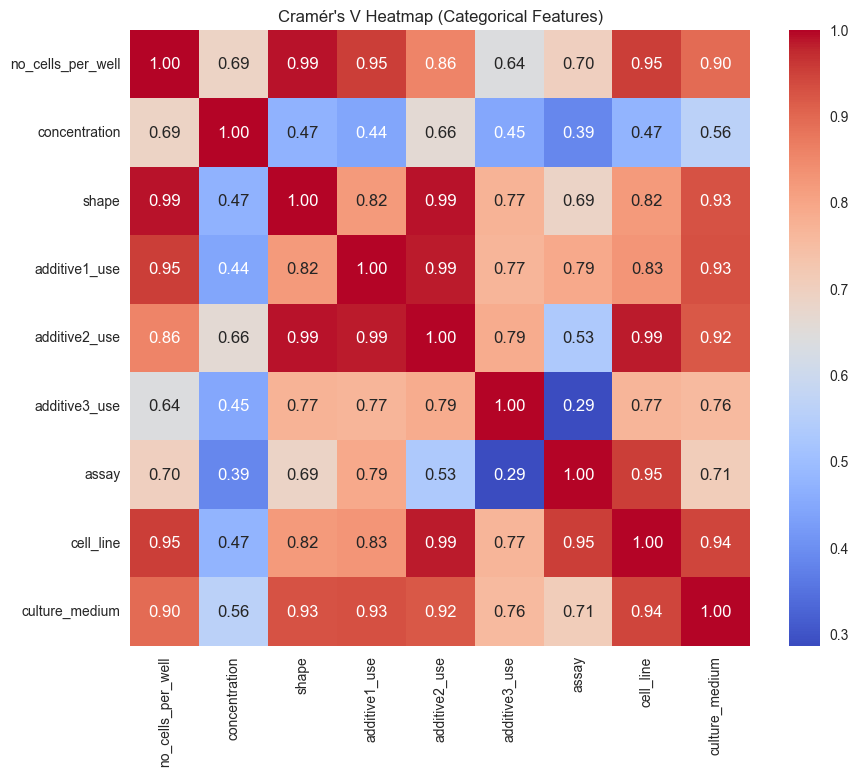

In [31]:
# Use cramer's V for categorical features between them
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))    
cat_cols = X_train_clean.select_dtypes(include=['object', 'category']).columns.tolist()
cramers_v_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)
for col1 in cat_cols:
    for col2 in cat_cols:
        if col1 == col2:
            cramers_v_matrix.loc[col1, col2] = 1.0
        else:
            cramers_v_matrix.loc[col1, col2] = cramers_v(X_train_clean[col1], X_train_clean[col2])
plt.figure(figsize=(10, 8))
sns.heatmap(cramers_v_matrix.astype(float), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Cramér's V Heatmap (Categorical Features)")
plt.show()

## Drop Unnecessary Features

In [32]:
# feature_to_drop = mi_scores_series.keys()[-1] # get the feature with the lowest MI score
# X_train_clean = X_train_clean.drop(columns=feature_to_drop)
# X_test_clean  = X_test_clean.drop(columns=feature_to_drop)
# print(f"Drop feature: {feature_to_drop}") 

# Machine Learning Algorithm

In [33]:
# Recompute numerical and categorical features 
numerical_cols = X_train_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_train_clean.columns
                    if c not in numerical_cols and c != target]

print(f"Numerical features ({len(numerical_cols)}):")
for c in numerical_cols: print(f"  - {c}")
print(f"\nCategorical features ({len(categorical_cols)}):")
for c in categorical_cols: print(f"  - {c}")

features_num = numerical_cols
features_cat = categorical_cols 

Numerical features (6):
  - hb_ratio
  - additive1_percentage
  - additive2_percentage
  - additive3_percentage
  - polymer_percentage
  - incubation_time

Categorical features (9):
  - no_cells_per_well
  - concentration
  - shape
  - additive1_use
  - additive2_use
  - additive3_use
  - assay
  - cell_line
  - culture_medium


In [34]:
# Preprocessing pipeline
def build_preprocessor(features_num, features_cat):
    """
    Returns a fresh, unfitted ColumnTransformer.
    Call this every time you need a new preprocessor instance
    """
    return ColumnTransformer(
        transformers=[
            (
                "num",
                StandardScaler(),
                features_num
            ),
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore",   
                    sparse_output=False,
                    drop="if_binary"           
                ),
                features_cat
            ),
        ],
        remainder="drop",  # drop any column not explicitly listed
    )

## Applicability Domain 

In [35]:
# Preprocessing only for Applicability domain
pre_ad = build_preprocessor(features_num, features_cat)
 
X_train_preprocessed = pre_ad.fit_transform(X_train_clean)
X_test_preprocessed  = pre_ad.transform(X_test_clean)
 
print("\nPreprocessed shapes:")
print(f"  X_train_preprocessed: {X_train_preprocessed.shape}")
print(f"  X_test_preprocessed:  {X_test_preprocessed.shape}")


Preprocessed shapes:
  X_train_preprocessed: (109, 45)
  X_test_preprocessed:  (27, 45)


In [36]:
# Applicability Domain check

doa_methods = {
    "Leverage":    Leverage(),
    "BoundingBox": BoundingBox()
}
 
in_doa_per_method = {}
for name, method in doa_methods.items():
    method.fit(X_train_preprocessed)
    preds = method.predict(X_test_preprocessed)
    in_doa_per_method[name] = np.array([bool(p["inDoa"]) for p in preds])
 
ad_df = pd.DataFrame(in_doa_per_method, index=X_test_clean.index)
ad_df["votes_in"]  = ad_df.sum(axis=1)
ad_df["votes_out"] = len(doa_methods) - ad_df["votes_in"]
ad_df["in_domain"] = ad_df["votes_in"] >= 2  # unanimous vote (must be in-domain in both methods)
 
print("\nPer-method in-domain counts (test set):")
for name in doa_methods:
    n_in  = int(ad_df[name].sum())
    n_out = int((~ad_df[name]).sum())
    print(f"  {name:<12}  in: {n_in:>3}   out: {n_out:>3}")
 
n_total  = len(ad_df)
n_in_maj = int(ad_df["in_domain"].sum())
print(f"\nUnanimous vote (>= 2/{len(doa_methods)} in-domain):")
print(f"  Kept (in-domain):     {n_in_maj} / {n_total}")
print(f"  Excluded (out-of-AD): {n_total - n_in_maj} / {n_total}")

# Preprocessed arrays no longer needed
del X_train_preprocessed, X_test_preprocessed, pre_ad




Per-method in-domain counts (test set):
  Leverage      in:  26   out:   1
  BoundingBox   in:  27   out:   0

Unanimous vote (>= 2/2 in-domain):
  Kept (in-domain):     26 / 27
  Excluded (out-of-AD): 1 / 27


In [37]:
# AD-filtered RAW test set - used for all evaluations below
in_domain_mask  = ad_df["in_domain"].values                              
X_test_clean_ad = X_test_clean.iloc[in_domain_mask].reset_index(drop=True)  
y_test_clean_ad = y_test_clean.iloc[in_domain_mask].reset_index(drop=True)  

In [38]:
y_train_clean.value_counts()

toxicity
non-toxic    86
toxic        23
Name: count, dtype: int64

## Pycaret Baseline model

In [32]:
# Built Pycaret's datasets
train_data = X_train_clean.copy()
train_data[target] = y_train_clean.values

test_data_ad = X_test_clean_ad.copy()
test_data_ad[target] = y_test_clean_ad.values


# Pycaret setup
clf = setup(data=train_data,
            test_data=test_data_ad,
            target=target,
            fold=NUM_SPLITS,
            preprocess=True,          
            fold_strategy=RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42),
            index=False, # not treat the index column as a feature
            session_id=42)

,Description,Value
0,Session id,42
1,Target,toxicity
2,Target type,Binary
3,Target mapping,"non-toxic: 0, toxic: 1"
4,Original data shape,"(135, 16)"
5,Transformed data shape,"(135, 46)"
6,Transformed train set shape,"(109, 46)"
7,Transformed test set shape,"(26, 46)"
8,Numeric features,6
9,Categorical features,9


In [33]:
# Baseline comparison   
baseline = compare_models(sort='mcc', n_select=1)

baseline_results = pull()
print("\n=== BASELINE RANKING (read top 3 from here) ===")
print(baseline_results[['Model', 'MCC', 'AUC', 'Recall', 'F1']].head(3).to_string())

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
catboost,CatBoost Classifier,0.9100,0.9570,0.9100,0.9172,0.9098,0.7285,0.7383,0.0872
ridge,Ridge Classifier,0.9009,0.9288,0.9009,0.9125,0.9024,0.7140,0.7245,0.0052
et,Extra Trees Classifier,0.9063,0.8706,0.9063,0.9119,0.9065,0.7174,0.7241,0.0134
rf,Random Forest Classifier,0.9063,0.9448,0.9063,0.9109,0.9058,0.7142,0.7215,0.0140
lr,Logistic Regression,0.9063,0.9335,0.9063,0.9119,0.9030,0.7030,0.7174,0.0586
xgboost,Extreme Gradient Boosting,0.9027,0.9354,0.9027,0.9096,0.9017,0.7034,0.7145,0.0070
gbc,Gradient Boosting Classifier,0.8981,0.9371,0.8981,0.9045,0.8980,0.6925,0.7005,0.0082
ada,Ada Boost Classifier,0.8926,0.9356,0.8926,0.9026,0.8931,0.6824,0.6936,0.0082
lda,Linear Discriminant Analysis,0.8770,0.9141,0.8770,0.9018,0.8826,0.6695,0.6850,0.0052
dt,Decision Tree Classifier,0.8880,0.8611,0.8880,0.8948,0.8871,0.6587,0.6694,0.0058



=== BASELINE RANKING (read top 3 from here) ===
                           Model     MCC     AUC  Recall      F1
catboost     CatBoost Classifier  0.7383  0.9570  0.9100  0.9098
ridge           Ridge Classifier  0.7245  0.9288  0.9009  0.9024
et        Extra Trees Classifier  0.7241  0.8706  0.9063  0.9065


In [34]:
# Optimize the best model's hyperparameters using Optuna with early stopping
tuned_model = tune_model(baseline,
                         optimize='mcc',
                         search_library='optuna',
                         n_iter=50,
                         )
# Check the best hyperparameters found
print("Best hyperparameters:", tuned_model.get_params())

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9091,0.8889,0.9091,0.9182,0.8963,0.6207,0.6708
1,0.9091,0.9000,0.9091,0.9091,0.9091,0.7412,0.7412
2,0.9091,0.9941,0.9091,0.9351,0.9138,0.7732,0.7939
3,0.9545,0.9941,0.9545,0.9571,0.9527,0.8608,0.8692
4,0.9524,0.9853,0.9524,0.9619,0.9543,0.8591,0.8677
5,0.9091,0.9861,0.9091,0.9091,0.9091,0.6944,0.6944
6,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,0.7727,0.8412,0.7727,0.7898,0.7796,0.3956,0.3985
8,0.9091,0.9471,0.9091,0.9091,0.9091,0.7412,0.7412


Best hyperparameters: {'depth': 5, 'l2_leaf_reg': 121, 'border_count': 254, 'verbose': False, 'random_strength': 0.35544826397691676, 'task_type': 'CPU', 'n_estimators': 297, 'random_state': 42, 'eta': 0.09427321835009424}


In [35]:
predict_model(tuned_model)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,CatBoost Classifier,0.8846,0.9208,0.8846,0.9231,0.8915,0.7234,0.7528


,hb_ratio,additive1_percentage,additive2_percentage,additive3_percentage,polymer_percentage,no_cells_per_well,concentration,incubation_time,shape,additive1_use,additive2_use,additive3_use,assay,cell_line,culture_medium,toxicity,prediction_label,prediction_score
109,88.0,42.130001,0.000000,0.00,57.869999,medium,medium,24.0,nanoparticle,anticancer,not_applicable,not_applicable,mtt,a549,dmem_fbs_p/s,non-toxic,toxic,0.8402
110,85.0,33.330002,33.330002,0.00,33.330002,low,very_low,48.0,nanospheres,targeting_ligand,stabilizer,not_applicable,mtt,mcf7,dmem_10fbs_pen_strep,non-toxic,non-toxic,0.9744
111,85.0,32.900002,32.900002,1.32,32.900002,low,very_low,48.0,nanospheres,targeting_ligand,stabilizer,active_drug,mtt,mcf7,dmem_10fbs_pen_strep,toxic,toxic,0.7133
112,100.0,33.330002,33.330002,0.00,33.330002,low,very_low,72.0,nanospheres,targeting_ligand,stabilizer,not_applicable,mtt,mcf7,dmem_10fbs_pen_strep,non-toxic,non-toxic,0.9666
113,85.0,33.330002,33.330002,0.00,33.330002,low,very_low,72.0,nanospheres,targeting_ligand,stabilizer,not_applicable,mtt,mcf7,dmem_10fbs_pen_strep,non-toxic,non-toxic,0.9665
114,85.0,32.900002,32.900002,1.32,32.900002,low,very_low,72.0,nanospheres,targeting_ligand,stabilizer,active_drug,mtt,mcf7,dmem_10fbs_pen_strep,toxic,toxic,0.8178
115,100.0,32.900002,32.900002,1.32,32.900002,low,very_low,48.0,nanospheres,targeting_ligand,stabilizer,active_drug,mtt,mcf7,dmem_10fbs_pen_strep,toxic,toxic,0.7098
116,88.0,0.000000,0.000000,0.00,100.000000,high,very_high,48.0,microsphere,not_applicable,not_applicable,not_applicable,diic1_5,jurkat,rpmi-1640,non-toxic,non-toxic,0.9714
117,85.0,32.900002,32.900002,1.32,32.900002,low,very_low,24.0,nanospheres,targeting_ligand,stabilizer,active_drug,mtt,mcf7,dmem_10fbs_pen_strep,non-toxic,non-toxic,0.8753
118,85.0,33.330002,33.330002,0.00,33.330002,low,very_low,24.0,nanospheres,targeting_ligand,stabilizer,not_applicable,mtt,mcf7,dmem_10fbs_pen_strep,non-toxic,non-toxic,0.9666


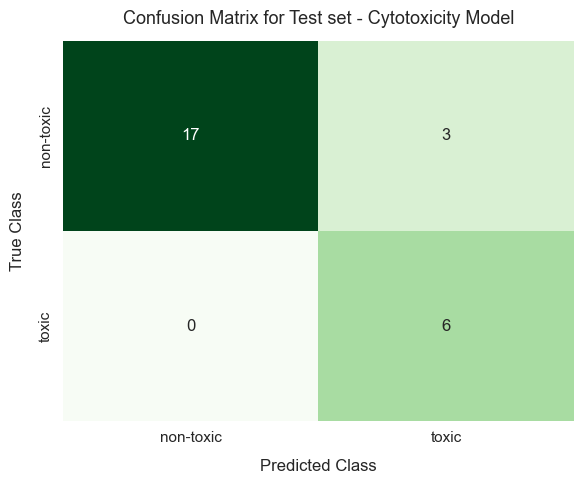

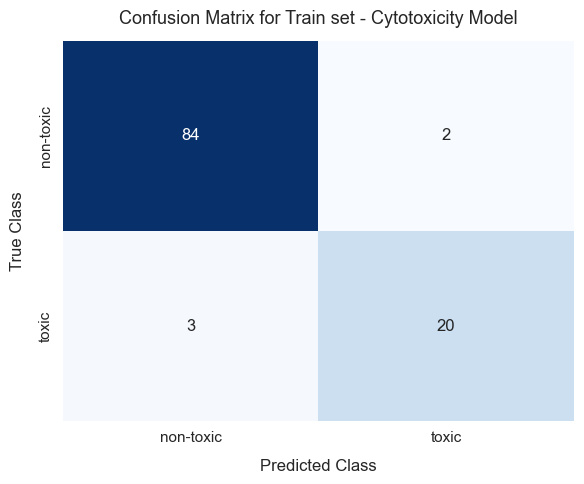

In [36]:
# Plot confusion matrix for train and test set based on the tuned model predictions
def plot_confusion_matrix(cm, title, color):
    plt.figure(figsize=(6, 5))
    ax = sns.heatmap(cm, annot=True, fmt='d', cmap=color, cbar=False)
    
    classes = sorted(y_train_clean.unique())
    ax.set_xticklabels(classes, fontsize=11)
    ax.set_yticklabels(classes, fontsize=11)    
    # Remove tick marks and spines
    ax.tick_params(which='both', bottom=False, left=False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xlabel('Predicted Class', fontsize=12, labelpad=10)
    ax.set_ylabel('True Class', fontsize=12, labelpad=10)
    ax.set_title(title, fontsize=13, pad=12)
    plt.tight_layout()
    # plt.savefig(f'{title.replace(" ", "_").lower()}.png', dpi=600, bbox_inches='tight')
    # plt.show()
    plt.show() 
    
predictions = predict_model(tuned_model, data=X_test_clean_ad)

X_test_pred = predictions['prediction_label']  # predicted classes
cm_test = confusion_matrix(y_test_clean_ad, X_test_pred)
plot_confusion_matrix(cm_test, 'Confusion Matrix for Test set - Cytotoxicity Model', 'Greens')

# Same for train
train_predictions = predict_model(tuned_model, data=X_train_clean)
X_train_pred = train_predictions['prediction_label']
cm_train = confusion_matrix(y_train_clean, X_train_pred)
plot_confusion_matrix(cm_train, 'Confusion Matrix for Train set - Cytotoxicity Model', 'Blues')

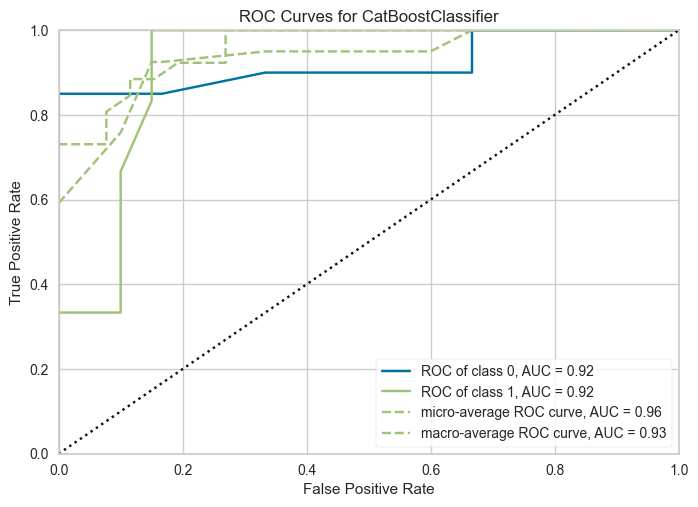

In [37]:
plot_model(tuned_model)

# Get Sample Rows for Final Dataset used for Training

In [58]:
sample_df = X_train_clean.copy()
sample_df[target] = y_train_clean
sample_df_fnl = sample_df.sample(20)
print(sample_df_fnl)
sample_df_fnl.to_excel('sample_20_cytotoxicity.xlsx', index=False)

     hb_ratio  additive1_percentage  additive2_percentage  \
102      85.0                 33.33                 33.33   
27       88.0                 20.30                  0.00   
3        88.0                  6.60                  0.00   
56       88.0                 12.50                  0.00   
92       88.0                 89.11                  0.99   
76       88.0                 42.13                  0.00   
67       88.0                 90.00                  0.00   
81       88.0                 42.13                  0.00   
72       85.0                 32.90                 32.90   
69      100.0                 33.33                 33.33   
13      100.0                 24.00                 33.00   
85      100.0                 32.90                 32.90   
31       85.0                 32.90                 32.90   
48      100.0                 32.90                 32.90   
47       88.0                  0.00                  0.00   
93       88.0           

# Final Train and Test Sets

In [110]:
Train_df_fnl = X_train_clean.copy()
Train_df_fnl[target] = y_train_clean
print(Train_df_fnl.sample(20))
Train_df_fnl.to_excel('final_train_set_cytotoxicity.xlsx', index=False)

    hb_ratio  additive1_percentage  additive2_percentage  \
76      88.0                 42.13                  0.00   
19     100.0                 27.00                 44.00   
5       85.0                 32.90                 32.90   
53     100.0                 28.00                 41.00   
62     100.0                 33.33                 33.33   
13     100.0                 24.00                 33.00   
61     100.0                 32.90                 32.90   
99      85.0                 32.90                 32.90   
87      85.0                 33.33                 33.33   
40     100.0                 32.90                 32.90   
16      85.0                 33.33                 33.33   
20      85.0                 33.33                 33.33   
85     100.0                 32.90                 32.90   
60     100.0                 20.00                 55.00   
72      85.0                 32.90                 32.90   
66      85.0                 33.33      

In [111]:
Test_df_fnl = X_test_clean_ad.copy()
Test_df_fnl[target] = y_test_clean_ad
print(Test_df_fnl.sample(20))
Test_df_fnl.to_excel('final_test_set_cytotoxicity.xlsx', index=False)

    hb_ratio  additive1_percentage  additive2_percentage  \
2       85.0                 32.90                 32.90   
9       85.0                 33.33                 33.33   
23      85.0                 33.33                 33.33   
14     100.0                 20.00                 55.00   
1       85.0                 33.33                 33.33   
18      85.0                 33.33                 33.33   
13      85.0                 33.33                 33.33   
8       85.0                 32.90                 32.90   
19     100.0                 32.90                 32.90   
21     100.0                 24.00                 33.00   
17     100.0                 32.90                 32.90   
7       88.0                  0.00                  0.00   
6      100.0                 32.90                 32.90   
24      88.0                 42.13                  0.00   
22     100.0                 33.33                 33.33   
16      85.0                 32.90      

# Jacpot Deployment

In [125]:
# Set train dataset for jaqpot
train_dataset = JaqpotTabularDataset(
                                    df=train_data,
                                    x_cols=train_data.drop(columns=[target]).columns.to_list(),
                                    y_cols=target,
                                    task="BINARY_CLASSIFICATION",
)

# Set test dataset for jaqpot
test_dataset = JaqpotTabularDataset(
                                    df=test_data_ad,
                                    x_cols=test_data_ad.drop(columns=[target]).columns.to_list(),
                                    y_cols=target,
                                    task="BINARY_CLASSIFICATION",
)

In [126]:
# Fix any remaining category dtype cols to object for jaqpotpy compatibility
cat_dtype_cols = train_data.select_dtypes("category").columns.tolist()
train_data[cat_dtype_cols] = train_data[cat_dtype_cols].astype(str)
test_data_ad[cat_dtype_cols] = test_data_ad[cat_dtype_cols].astype(str)

In [127]:
JAQPOT_COMPATIBLE_CLASSIFIERS = [
    'AdaBoostClassifier',
    'BaggingClassifier',
    'BernoulliNB',
    'CalibratedClassifierCV',
    'CategoricalNB',
    'ComplementNB',
    'DecisionTreeClassifier',
    'ExtraTreeClassifier',
    'ExtraTreesClassifier',
    'GaussianNB',
    'GaussianProcessClassifier',
    'GradientBoostingClassifier',
    'HistGradientBoostingClassifier',
    'KNeighborsClassifier',
    'LinearSVC',
    'LogisticRegression',       
    'MLPClassifier',
    'MultinomialNB',
    'OneVsOneClassifier',
    'OneVsRestClassifier',
    'QuadraticDiscriminantAnalysis',
    'RadiusNeighborsClassifier',
    'RandomForestClassifier',
    'SGDClassifier',
    'SVC',
    'StackingClassifier',
    'VotingClassifier',
    'RidgeClassifier',           
    'LinearDiscriminantAnalysis', 
]

# Tree-based models: capture non-linear relationships in small heterogeneous
# datasets and support exact SHAP computation via TreeExplainer
TREE_BASED_CLASSIFIERS = {
    'DecisionTreeClassifier',
    'ExtraTreeClassifier',
    'ExtraTreesClassifier',
    'GradientBoostingClassifier',
    'HistGradientBoostingClassifier',
    'RandomForestClassifier',
}

# Compare models and get top 5 by MCC
best_results = compare_models(sort='mcc', n_select=5)

# Best Jaqpot-compatible tree-based model (MCC rank preserved from PyCaret)
chosen_model = None
for m in best_results:
    if type(m).__name__ in JAQPOT_COMPATIBLE_CLASSIFIERS and type(m).__name__ in TREE_BASED_CLASSIFIERS:
        chosen_model = m
        print(f"Selected tree-based model: {type(m).__name__}")
        break

# Fallback to any Jaqpot-compatible model if no tree-based found
if chosen_model is None:
    for m in best_results:
        if type(m).__name__ in JAQPOT_COMPATIBLE_CLASSIFIERS:
            chosen_model = m
            print(f"No tree-based model in top results, falling back to: {type(m).__name__}")
            break

# Tune the selected model
print(f"\nTuning {type(chosen_model).__name__}...")
tuned_chosen = tune_model(chosen_model,
                          optimize='mcc',
                          search_library='optuna',
                          n_iter=50
                          )
final_model = type(tuned_chosen)(**tuned_chosen.get_params())
print("Tuning complete")

# Fit train data to jaqpot
jaqpot_model = SklearnModel(
                            dataset=train_dataset,
                            model=final_model,
                            doa=[Leverage(), BoundingBox()],
                            preprocess_x=build_preprocessor(features_num, features_cat)
)
jaqpot_model.random_seed = 1231
jaqpot_model.fit()
print("Jaqpot model ready")

Selected tree-based model: ExtraTreesClassifier

Tuning ExtraTreesClassifier...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9091,0.9444,0.9091,0.9182,0.8963,0.6207,0.6708
1,0.9091,0.8471,0.9091,0.9091,0.9091,0.7412,0.7412
2,0.9091,1.0000,0.9091,0.9351,0.9138,0.7732,0.7939
3,0.9545,0.9941,0.9545,0.9621,0.9559,0.8791,0.8856
4,0.9524,0.9853,0.9524,0.9619,0.9543,0.8591,0.8677
5,0.9545,0.9861,0.9545,0.9636,0.9564,0.8608,0.8692
6,0.9545,1.0000,0.9545,0.9571,0.9527,0.8608,0.8692
7,0.8636,0.9588,0.8636,0.9148,0.8728,0.6796,0.7174
8,0.9545,0.9765,0.9545,0.9621,0.9559,0.8791,0.8856


  2026-05-27 14:01:03,742 - INFO - Searching the best hyperparameters using 109 samples...
  2026-05-27 14:04:26,499 - INFO - Finished hyperparameter search!


Tuning complete
Goodness-of-fit metrics on training set:
{'accuracy': 0.944954128440367, 'balancedAccuracy': 0.949191102123357, 'precision': array([0.94186047, 0.95652174]), 'recall': array([0.98780488, 0.81481481]), 'f1Score': array([0.96428571, 0.88      ]), 'jaccard': array([0.93103448, 0.78571429]), 'matthewsCorrCoef': 0.8491520763953988, 'confusionMatrix': array([[81,  5],
       [ 1, 22]])}
Jaqpot model ready


In [129]:
tuned_chosen.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': 'balanced',
 'criterion': 'entropy',
 'max_depth': 8,
 'max_features': 0.8346239071969508,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.001223311287665157,
 'min_samples_leaf': 1,
 'min_samples_split': 4,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 55,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [1]:
X_train_clean.head(10)

NameError: name 'X_train_clean' is not defined

In [137]:
# Perform cross-validation on the training data
cv_results = jaqpot_model.cross_validate(train_dataset, n_splits=NUM_SPLITS)
cv_results

{'accuracy': 0.9172727272727274,
 'balancedAccuracy': 0.9067424242424243,
 'precision': array([0.94757576, 0.775     ]),
 'recall': array([0.95527778, 0.75      ]),
 'f1Score': array([0.94716276, 0.71904762]),
 'jaccard': array([0.90285354, 0.625     ]),
 'matthewsCorrCoef': 0.706561916939217,
 'confusionMatrix': array([[8.1, 0.5],
        [0.4, 1.9]])}

In [138]:
# Evaluate the model on the test dataset
test_results = jaqpot_model.evaluate(test_dataset)
test_results

{'accuracy': 0.8846153846153846,
 'balancedAccuracy': 0.925,
 'precision': array([0.85, 1.  ]),
 'recall': array([1.        , 0.66666667]),
 'f1Score': array([0.91891892, 0.8       ]),
 'jaccard': array([0.85      , 0.66666667]),
 'matthewsCorrCoef': 0.7527726527090811,
 'confusionMatrix': array([[17,  3],
        [ 0,  6]])}

In [ ]:
# Conduct a randomization test to assess the model's robustness
jaqpot_model.randomization_test(
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    n_iters=10,
)

{'iteration_0': {'Train': {'accuracy': 0.8807339449541285,
   'balancedAccuracy': 0.9244186046511628,
   'precision': array([0.84883721, 1.        ]),
   'recall': array([1.        , 0.63888889]),
   'f1Score': array([0.91823899, 0.77966102]),
   'jaccard': array([0.84883721, 0.63888889]),
   'matthewsCorrCoef': 0.7364188084905953,
   'confusionMatrix': array([[73, 13],
          [ 0, 23]])},
  'Test': {'accuracy': 0.5384615384615384,
   'balancedAccuracy': 0.4083333333333333,
   'precision': array([0.65      , 0.16666667]),
   'recall': array([0.72222222, 0.125     ]),
   'f1Score': array([0.68421053, 0.14285714]),
   'jaccard': array([0.52      , 0.07692308]),
   'matthewsCorrCoef': -0.16735967034880075,
   'confusionMatrix': array([[13,  7],
          [ 5,  1]])}},
 'iteration_1': {'Train': {'accuracy': 0.8440366972477065,
   'balancedAccuracy': 0.9011627906976745,
   'precision': array([0.80232558, 1.        ]),
   'recall': array([1.   , 0.575]),
   'f1Score': array([0.89032258, 0

## Applicability Domain

In [132]:
doa_predictions = jaqpot_model.predict_doa(test_dataset)

summary = {}
for key in ['LEVERAGE','BOUNDING_BOX']:
    df_doa = pd.DataFrame(doa_predictions[key])
    summary[key] = {
        'n_total': len(df_doa),
        'n_in': int(df_doa['inDoa'].sum()),
        'n_out': int((~df_doa['inDoa']).sum())
    }
summary


{'LEVERAGE': {'n_total': 26, 'n_in': 26, 'n_out': 0},
 'BOUNDING_BOX': {'n_total': 26, 'n_in': 26, 'n_out': 0}}

## Confusion Matrix

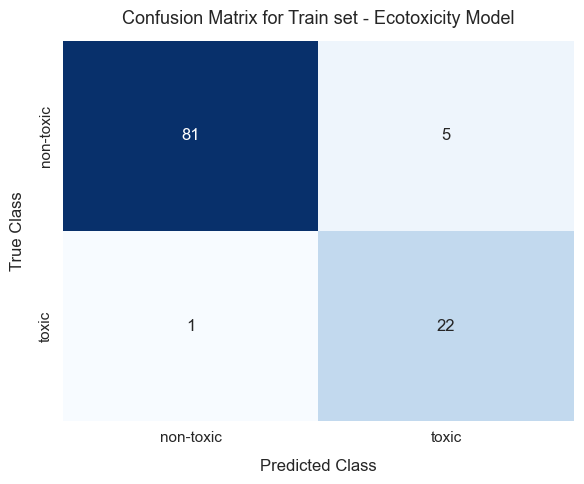

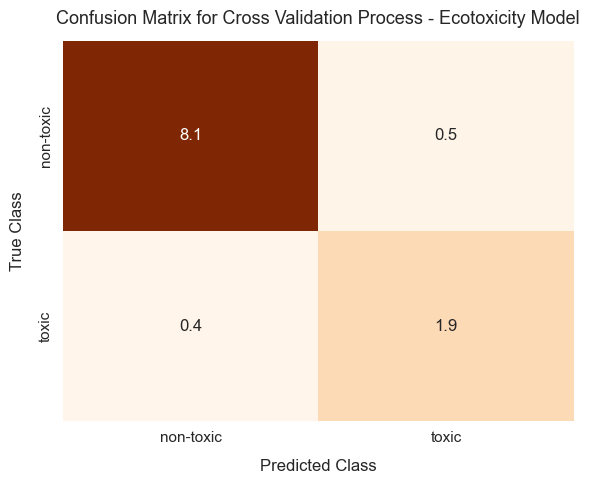

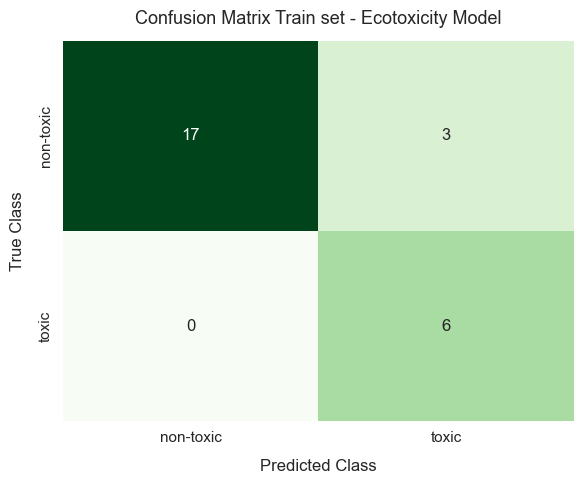

In [139]:
# Plot confusion matrix for train and test set based on the tuned model predictions
def plot_confusion_matrix(cm, title, color, fmt='d'):
    plt.figure(figsize=(6, 5))
    ax = sns.heatmap(cm, annot=True, fmt=fmt, cmap=color, cbar=False)
    
    classes = sorted(y_train_clean.unique())
    ax.set_xticklabels(classes, fontsize=11)
    ax.set_yticklabels(classes, fontsize=11)    
    # Remove tick marks and spines
    ax.tick_params(which='both', bottom=False, left=False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xlabel('Predicted Class', fontsize=12, labelpad=10)
    ax.set_ylabel('True Class', fontsize=12, labelpad=10)
    ax.set_title(title, fontsize=13, pad=12)
    plt.tight_layout()
    # plt.savefig(f'{title.replace(" ", "_").lower()}.png', dpi=600, bbox_inches='tight')
    plt.show() 
    
# Confusion matrix for train set
train_results = jaqpot_model.train_scores
cm_train = train_results['confusionMatrix']
plot_confusion_matrix(cm_train, 'Confusion Matrix for Train set - Ecotoxicity Model', 'Blues')

# Confusion matrix for cv in train set
cm_cv = cv_results['confusionMatrix']
plot_confusion_matrix(cm_cv, 'Confusion Matrix for Cross Validation Process - Ecotoxicity Model', 'Oranges', fmt='.1f')

# Confusion matrix for test set
cm_test = test_results['confusionMatrix']
plot_confusion_matrix(cm_test, 'Confusion Matrix Train set - Ecotoxicity Model', 'Greens')



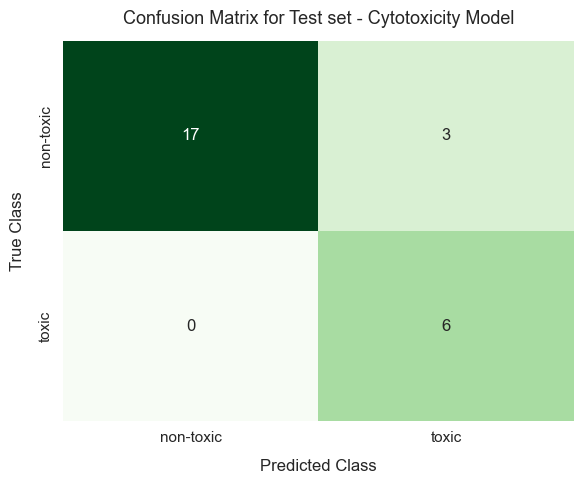

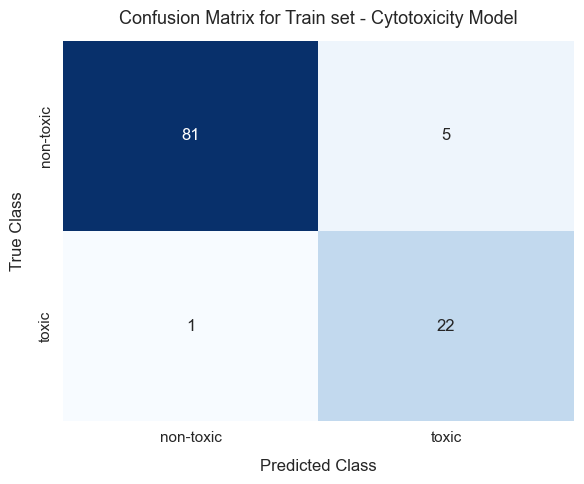

In [133]:
# Plot confusion matrix for train and test set based on the tuned model predictions
def plot_confusion_matrix(cm, title, color):
    plt.figure(figsize=(6, 5))
    ax = sns.heatmap(cm, annot=True, fmt='d', cmap=color, cbar=False)
    
    classes = sorted(y_train_clean.unique())
    ax.set_xticklabels(classes, fontsize=11)
    ax.set_yticklabels(classes, fontsize=11)    
    # Remove tick marks and spines
    ax.tick_params(which='both', bottom=False, left=False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xlabel('Predicted Class', fontsize=12, labelpad=10)
    ax.set_ylabel('True Class', fontsize=12, labelpad=10)
    ax.set_title(title, fontsize=13, pad=12)
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_").lower()}.png', dpi=600, bbox_inches='tight')
    plt.show() 
    
predictions = predict_model(tuned_chosen, data=X_test_clean_ad)

X_test_pred = predictions['prediction_label']  # predicted classes
cm_test = confusion_matrix(y_test_clean_ad, X_test_pred)
plot_confusion_matrix(cm_test, 'Confusion Matrix for Test set - Cytotoxicity Model', 'Greens')

# Same for train
train_predictions = predict_model(tuned_chosen, data=X_train_clean)
X_train_pred = train_predictions['prediction_label']
cm_train = confusion_matrix(y_train_clean, X_train_pred)
plot_confusion_matrix(cm_train, 'Confusion Matrix for Train set - Cytotoxicity Model', 'Blues')

## SHAP plots

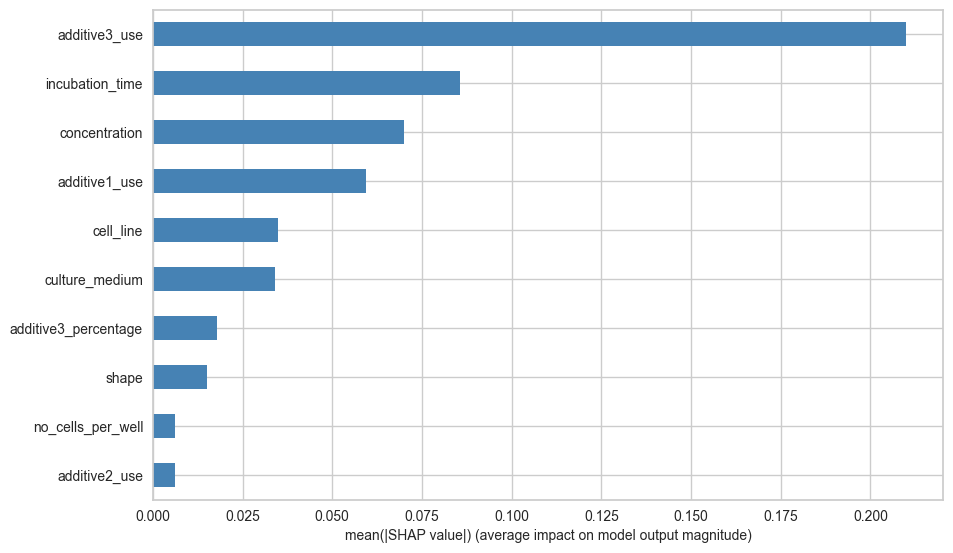

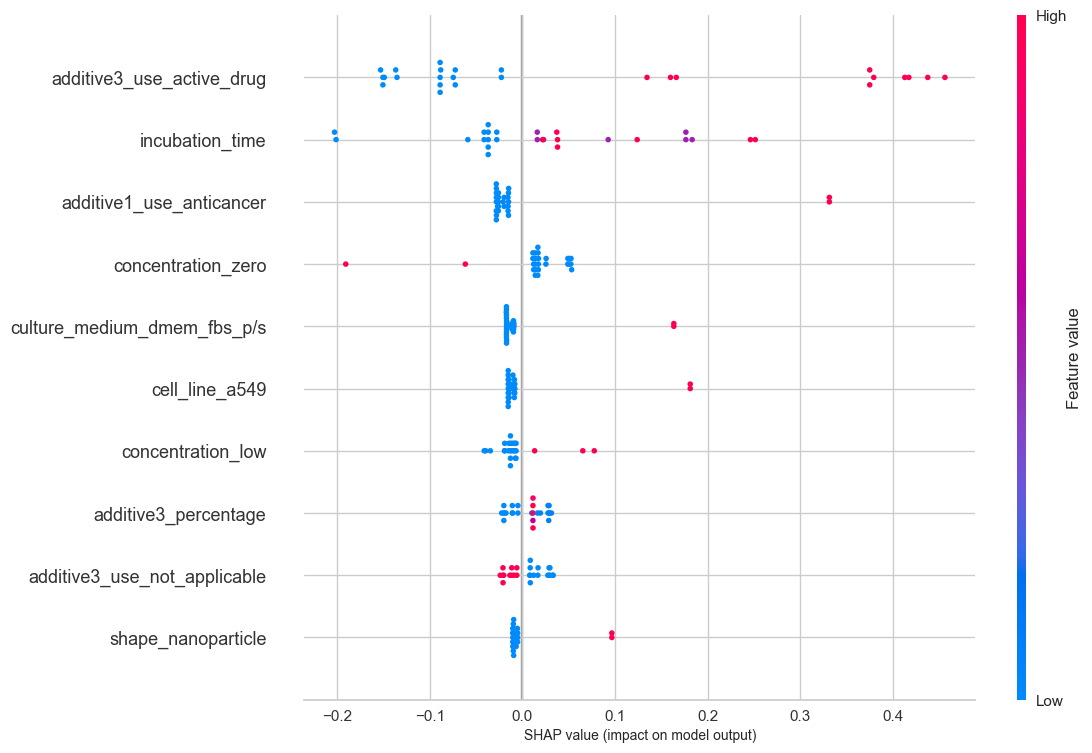

In [134]:
X_train_transformed = get_config("X_train_transformed")
X_test_transformed  = get_config("X_test_transformed")

explainer = shap.TreeExplainer(tuned_chosen, X_train_transformed)
shap_values = explainer.shap_values(X_test_transformed)

# Handle both SHAP output formats for binary classification
if isinstance(shap_values, list):
    sv = shap_values[1]          # older SHAP: list of (samples, features)
elif shap_values.ndim == 3:
    sv = shap_values[:, :, 1]   # newer SHAP: (samples, features, classes)
else:
    sv = shap_values             # single output model

# ── Bar plot: aggregated by original feature name ─────────────────────────

def get_original_feature(col, features_num, features_cat):
    """Map an OHE column name back to its original feature name."""
    if col in features_num:
        return col
    for cat in features_cat:
        if col.startswith(cat + '_') or col == cat:
            return cat
    return col  # fallback: keep as-is

# Build column → original feature mapping
col_to_original = {
    col: get_original_feature(col, features_num, features_cat)
    for col in X_test_transformed.columns
}

# Aggregate mean(|SHAP|) per original feature
shap_df = pd.DataFrame(sv, columns=X_test_transformed.columns)

aggregated_shap = (
    shap_df
    .abs()
    .rename(columns=col_to_original)
    .T
    .groupby(level=0)
    .sum()
    .T
    .mean(axis=0)
    .sort_values(ascending=True)
)

# Plot top 10
top_n = 10
top_features = aggregated_shap.tail(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
top_features.plot.barh(ax=ax, color='steelblue', legend=False)
ax.set_xlabel("mean(|SHAP value|) (average impact on model output magnitude)", fontsize=10)
ax.set_ylabel("")
plt.tight_layout(pad=2.0)
plt.savefig('shap_bar_plot_cytotoxicity_model.png', dpi=600, bbox_inches='tight')
plt.show()

# ── Beeswarm plot: full OHE feature names ─────────────────────────────────

shap.summary_plot(sv, X_test_transformed,
                  feature_names=X_test_transformed.columns.tolist(),
                  show=False, max_display=10)
plt.gcf().set_size_inches(12, 8)
plt.xlabel("SHAP value (impact on model output)", fontsize=10)
plt.tight_layout(pad=2.0)
plt.savefig('shap_beeswarm_plot_cytotoxicity_model.png', dpi=600, bbox_inches='tight')
plt.show()

## Upload Model on Jaqpot

In [ ]:
# Upload the pretrained model on Jaqpot
jaqpot = Jaqpot()
jaqpot.login()
jaqpot_model.deploy_on_jaqpot(
    jaqpot=jaqpot,
    name="Ecotoxicity classification model for PHBV polymers A.N.I.P.H.",
    description="Predict cytotoxicity of PHBV polymers.",
    visibility="PUBLIC",
)

Open this URL in your browser and log in:
https://login.jaqpot.org/realms/jaqpot/protocol/openid-connect/auth?client_id=jaqpot-client&response_type=code&redirect_uri=urn:ietf:wg:oauth:2.0:oob&scope=openid email profile&state=random_state_value&nonce=


  2026-05-27 14:05:27,758 - INFO - Model has been successfully uploaded. The url of the model is https://app.jaqpot.org/dashboard/models/2367
